Task 1.1 - Number of rows: 54960961
Task 1.2 - Number of unique IDs: 1430445
Task 1.3 - Earliest timestamp: 2020-11-03T03:31:30Z
Task 1.3 - Latest timestamp: 2023-01-23T12:29:56Z
Task 2.1 - Number of duplicates: 3112100
Task 2.1 - Proportion of duplicates: 0.056623827956720045
Task 2.2 - Rows after removing duplicates: 51848861


/var/folders/6q/gyhc4y6d505c6js05zp92gx40000gn/T/ipykernel_15972/2322290015.py:70: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  df_sample = df.filter(pl.col("id").is_in(sample_ids["id"])).collect()


Task 3.1 - Journey length stats:
shape: (1, 5)
┌──────────┬────────┬───────────┬─────┬──────┐
│ mean     ┆ median ┆ std       ┆ min ┆ max  │
│ ---      ┆ ---    ┆ ---       ┆ --- ┆ ---  │
│ f64      ┆ f64    ┆ f64       ┆ u32 ┆ u32  │
╞══════════╪════════╪═══════════╪═════╪══════╡
│ 38.73076 ┆ 26.0   ┆ 44.405136 ┆ 1   ┆ 2708 │
└──────────┴────────┴───────────┴─────┴──────┘
Task 3.1 - Journey duration (seconds):
shape: (1, 3)
┌──────────┬────────────┬──────────┐
│ mean_sec ┆ median_sec ┆ max_sec  │
│ ---      ┆ ---        ┆ ---      │
│ f64      ┆ f64        ┆ i64      │
╞══════════╪════════════╪══════════╡
│ 1.1557e7 ┆ 8443827.5  ┆ 37868407 │
└──────────┴────────────┴──────────┘
Task 3.2 - Most common actions:
shape: (10, 2)
┌──────────────────────────┬─────────┐
│ event_name               ┆ count   │
│ ---                      ┆ ---     │
│ str                      ┆ u32     │
╞══════════════════════════╪═════════╡
│ browse_products          ┆ 1386580 │
│ application_web_view     ┆ 54

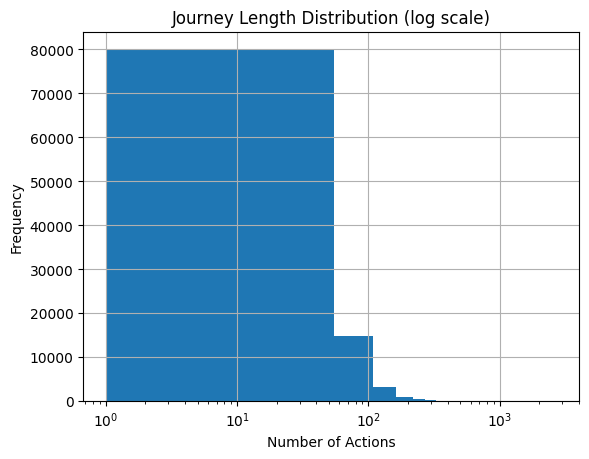

Figure 2: Time between actions distribution


<Figure size 640x480 with 0 Axes>

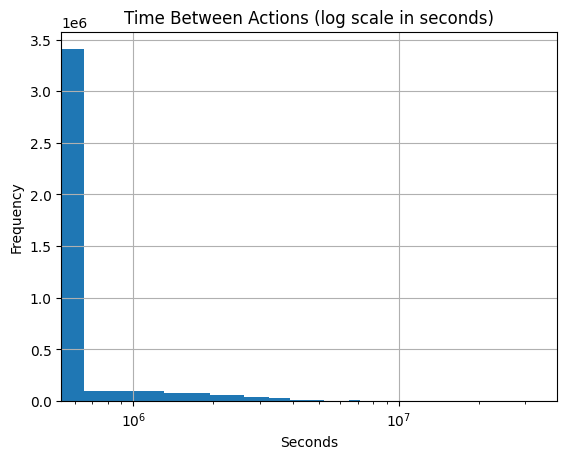

Figure 3: Most common actions


<Figure size 640x480 with 0 Axes>

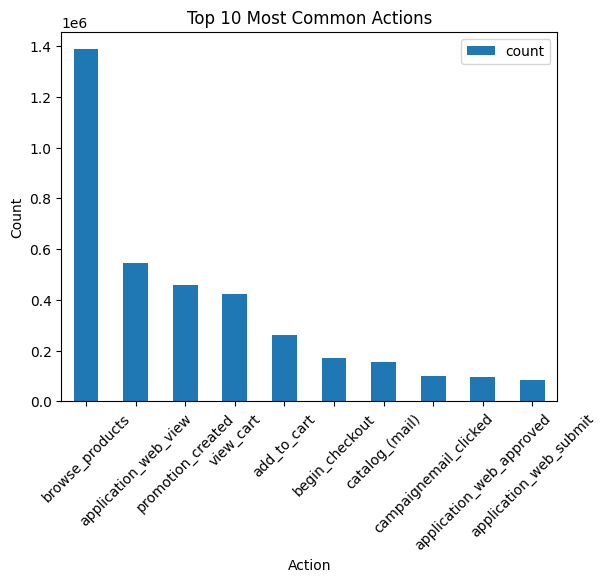

Task 4 - Flattened journey dataset preview:
shape: (5, 10)
┌────────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬─────────┐
│ id         ┆ journey   ┆ num_actio ┆ num_uniqu ┆ … ┆ duration_ ┆ first_act ┆ last_acti ┆ shipped │
│ ---        ┆ ---       ┆ ns        ┆ e_actions ┆   ┆ seconds   ┆ ion       ┆ on        ┆ ---     │
│ str        ┆ list[stru ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ bool    │
│            ┆ ct[2]]    ┆ u32       ┆ u32       ┆   ┆ i64       ┆ str       ┆ str       ┆         │
╞════════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═════════╡
│ -100000127 ┆ [{2022-10 ┆ 7         ┆ 4         ┆ … ┆ 2868448   ┆ applicati ┆ browse_pr ┆ false   │
│ 1          ┆ -31       ┆           ┆           ┆   ┆           ┆ on_web_ap ┆ oducts    ┆         │
│ 551641434  ┆ 13:45:59  ┆           ┆           ┆   ┆           ┆ proved    ┆           ┆         │
│            ┆ UTC,"app… ┆      

<Figure size 640x480 with 0 Axes>

In [5]:
import polars as pl
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "requirements.txt").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = PROJECT_ROOT / "data"
FIGURE_DIR = PROJECT_ROOT / "figures"
SUBMISSION_DIR = PROJECT_ROOT / "results" / "submissions"
for directory in (FIGURE_DIR, SUBMISSION_DIR):
    directory.mkdir(parents=True, exist_ok=True)

DATA_PATH = DATA_DIR / "dat_train1.csv"
CLEAN_PATH = DATA_DIR / "dat_train1_clean.csv"

# lazy load
df = pl.scan_csv(DATA_PATH)


## task 1

#1.1
num_rows = df.select(pl.len()).collect().item()
#1.2
num_unique_ids = df.select(pl.col("id").n_unique()).collect().item()

#1.3
earliest, latest = df.select([
    pl.col("event_timestamp").min().alias("earliest"),
    pl.col("event_timestamp").max().alias("latest")
]).collect().row(0)



print("Task 1.1 - Number of rows:", num_rows)

print("Task 1.2 - Number of unique IDs:", num_unique_ids)

print("Task 1.3 - Earliest timestamp:", earliest)
print("Task 1.3 - Latest timestamp:", latest)
## task 2

#2.1
total = num_rows

unique = df.unique(
    subset=["id", "event_name", "event_timestamp"]
).select(pl.len()).collect().item()

duplicates = total - unique
proportion = duplicates / total

# remove duplicates
df_clean = df.unique(subset=["id", "event_name", "event_timestamp"])

# fix the action counter
df_clean = df_clean.sort(["id", "event_timestamp"]).with_columns(
    pl.int_range(1, pl.len() + 1).over("id").alias("journey_steps_until_end")
)

df_clean.collect().write_csv(CLEAN_PATH)

#2.2
df_clean = pl.scan_csv(CLEAN_PATH)

num_rows_clean = df_clean.select(pl.len()).collect().item()

print("Task 2.1 - Number of duplicates:", duplicates)
print("Task 2.1 - Proportion of duplicates:", proportion)

print("Task 2.2 - Rows after removing duplicates:", num_rows_clean)


## task 3

# sample
unique_ids = df.select("id").unique().collect()
# sample 100k ids
sample_ids = unique_ids.sample(n=100000, shuffle=True)
# filter full df by sampled ids
df_sample = df.filter(pl.col("id").is_in(sample_ids["id"])).collect()

# parse timestamp once
df_sample = df_sample.with_columns(
    pl.col("event_timestamp").str.strptime(
        pl.Datetime,
        format="%Y-%m-%dT%H:%M:%SZ"
    )
)

# # 3.1
actions_per_journey = df_sample.group_by("id").agg(
    pl.len().alias("num_actions")
)

journey_time = df_sample.group_by("id").agg(
    (pl.col("event_timestamp").max() - pl.col("event_timestamp").min()).alias("duration")
)
journey_time_seconds = journey_time.with_columns(
    pl.col("duration").dt.total_seconds().alias("duration_sec")
)

# 3.2
common_actions = df_sample.group_by("event_name").agg(
    pl.len().alias("count")
).sort("count", descending=True)

# 3.3
time_between = df_sample.sort(["id", "event_timestamp"]).with_columns(
    (pl.col("event_timestamp") - pl.col("event_timestamp").shift(1))
    .over("id")
    .alias("time_diff")
)
time_between_seconds = time_between.with_columns(
    pl.col("time_diff").dt.total_seconds().alias("time_diff_sec")
)

# # 3.4
# print(actions_per_journey.describe())
# actions_per_journey.to_pandas().hist(column="num_actions")

# figures
import matplotlib.pyplot as plt


print("Task 3.1 - Journey length stats:")
print(actions_per_journey.select([
    pl.col("num_actions").mean().alias("mean"),
    pl.col("num_actions").median().alias("median"),
    pl.col("num_actions").std().alias("std"),
    pl.col("num_actions").min().alias("min"),
    pl.col("num_actions").max().alias("max"),
]))

print("Task 3.1 - Journey duration (seconds):")
print(journey_time_seconds.select([
    pl.col("duration_sec").mean().alias("mean_sec"),
    pl.col("duration_sec").median().alias("median_sec"),
    pl.col("duration_sec").max().alias("max_sec"),
]))

print("Task 3.2 - Most common actions:")
print(common_actions.head(10))
print("Task 3.3")
print(time_between_seconds.select([
    pl.col("time_diff_sec").mean().alias("mean_sec"),
    pl.col("time_diff_sec").median().alias("median_sec"),
    pl.col("time_diff_sec").max().alias("max_sec"),
]))

print("Task 3.4 - Distribution of journey lengths:")
print(actions_per_journey.describe())

print("Figure 1: Journey length distribution")
actions_per_journey.to_pandas().hist(column="num_actions", bins=50)
plt.xscale("log")
plt.title("Journey Length Distribution (log scale)")
plt.xlabel("Number of Actions")
plt.ylabel("Frequency")
plt.savefig(FIGURE_DIR / "fig1_journey_length.png")
plt.show()
plt.clf()

print("Figure 2: Time between actions distribution")
time_between_seconds.select("time_diff_sec").to_pandas().hist(bins=50)
plt.xscale("log")
plt.title("Time Between Actions (log scale in seconds)")
plt.xlabel("Seconds")
plt.ylabel("Frequency")
plt.savefig(FIGURE_DIR / "fig2_time_between.png")
plt.show()
plt.clf()

print("Figure 3: Most common actions")
common_actions.head(10).to_pandas().plot.bar(
    x="event_name", y="count"
)
plt.title("Top 10 Most Common Actions")
plt.xlabel("Action")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.savefig(FIGURE_DIR / "fig3_common_actions.png")
plt.show()
plt.clf()


## task 4
def flatten_journeys_parquet(input_csv_path, output_parquet_path):
    """
    Removes duplicates and flattens an event csv file so each journey (id)
    is one row, with the ordered journey stored as structs
    ["event_timestamp", "ed_id"] plus summary features.
    """
    q = pl.scan_csv(input_csv_path)
    q = q.unique(subset=["id", "ed_id", "event_timestamp"])
    q = q.with_columns(
        pl.col("event_timestamp").str.to_datetime(time_zone="UTC")
    )
    q = q.sort(["id", "event_timestamp", "ed_id"])

    df = (
        q.group_by("id")
        #this is modiied and not in the github as of 4/15
        .agg([
            pl.struct(["event_timestamp", "event_name"])
            .alias("journey"),

            pl.len().alias("num_actions"),
            pl.col("event_name").n_unique().alias("num_unique_actions"),

            pl.col("event_timestamp").min().alias("start_time"),
            pl.col("event_timestamp").max().alias("end_time"),

            (pl.col("event_timestamp").max() - pl.col("event_timestamp").min())
            .dt.total_seconds()
            .alias("duration_seconds"),

            pl.col("event_name").first().alias("first_action"),
            pl.col("event_name").last().alias("last_action"),

            pl.col("event_name")
            .eq("order_shipped")
            .any()
            .alias("shipped")
        ])
    )

    df.sink_parquet(output_parquet_path)

training_csv_path = DATA_PATH
output_path = DATA_DIR / "journeys_flattened.parquet"

flatten_journeys_parquet(training_csv_path, output_path)

df = pl.read_parquet(output_path)
print("Task 4 - Flattened journey dataset preview:")
print(df.head())

Task 3.1 - Journey length stats:
shape: (1, 5)
┌──────────┬────────┬───────────┬─────┬──────┐
│ mean     ┆ median ┆ std       ┆ min ┆ max  │
│ ---      ┆ ---    ┆ ---       ┆ --- ┆ ---  │
│ f64      ┆ f64    ┆ f64       ┆ u32 ┆ u32  │
╞══════════╪════════╪═══════════╪═════╪══════╡
│ 38.73076 ┆ 26.0   ┆ 44.405136 ┆ 1   ┆ 2708 │
└──────────┴────────┴───────────┴─────┴──────┘
Task 3.1 - Journey duration (seconds):
shape: (1, 3)
┌──────────┬────────────┬──────────┐
│ mean_sec ┆ median_sec ┆ max_sec  │
│ ---      ┆ ---        ┆ ---      │
│ f64      ┆ f64        ┆ i64      │
╞══════════╪════════════╪══════════╡
│ 1.1557e7 ┆ 8443827.5  ┆ 37868407 │
└──────────┴────────────┴──────────┘
Task 3.2 - Most common actions:
shape: (10, 2)
┌──────────────────────────┬─────────┐
│ event_name               ┆ count   │
│ ---                      ┆ ---     │
│ str                      ┆ u32     │
╞══════════════════════════╪═════════╡
│ browse_products          ┆ 1386580 │
│ application_web_view     ┆ 54

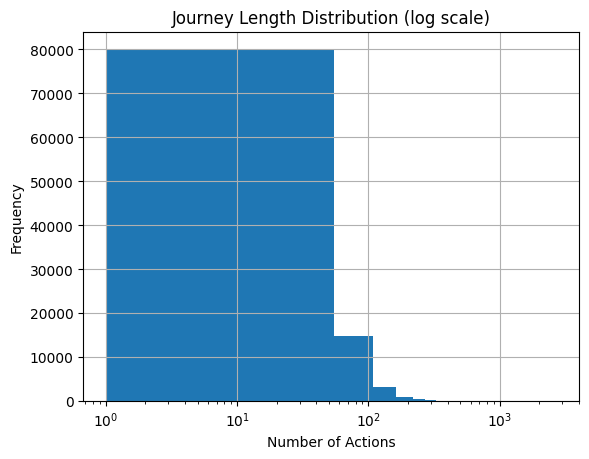

Figure 2: Time between actions distribution


<Figure size 640x480 with 0 Axes>

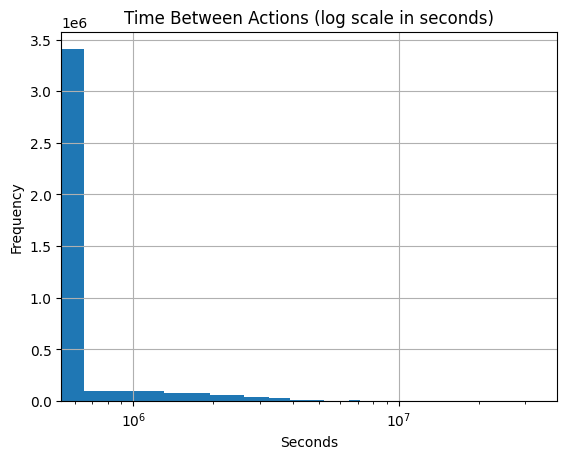

Figure 3: Most common actions


<Figure size 640x480 with 0 Axes>

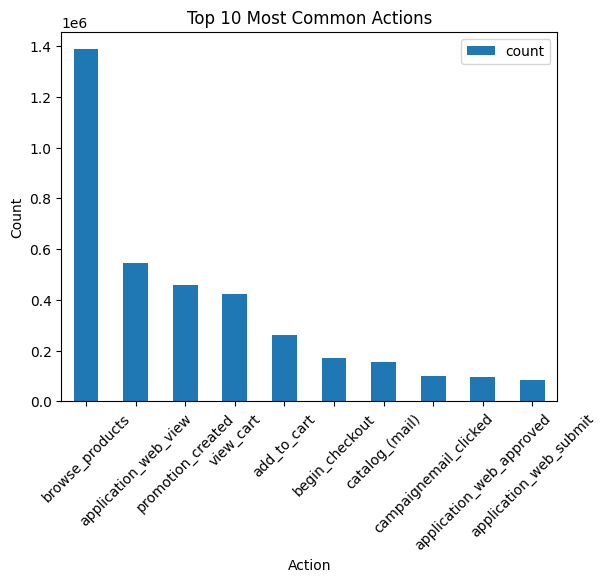

Task 4 - Flattened journey dataset preview:
shape: (5, 9)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ id        ┆ journey   ┆ num_actio ┆ num_uniqu ┆ … ┆ end_time  ┆ duration_ ┆ first_act ┆ last_act │
│ ---       ┆ ---       ┆ ns        ┆ e_actions ┆   ┆ ---       ┆ seconds   ┆ ion       ┆ ion      │
│ str       ┆ list[stru ┆ ---       ┆ ---       ┆   ┆ datetime[ ┆ ---       ┆ ---       ┆ ---      │
│           ┆ ct[2]]    ┆ u32       ┆ u32       ┆   ┆ μs, UTC]  ┆ i64       ┆ i64       ┆ i64      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ -10000012 ┆ [{2022-10 ┆ 7         ┆ 4         ┆ … ┆ 2022-12-0 ┆ 2868448   ┆ 12        ┆ 4        │
│ 71        ┆ -31       ┆           ┆           ┆   ┆ 3         ┆           ┆           ┆          │
│ 551641434 ┆ 13:45:59  ┆           ┆           ┆   ┆ 18:33:27  ┆           ┆           ┆          │
│           ┆ UTC,12},… ┆        

<Figure size 640x480 with 0 Axes>

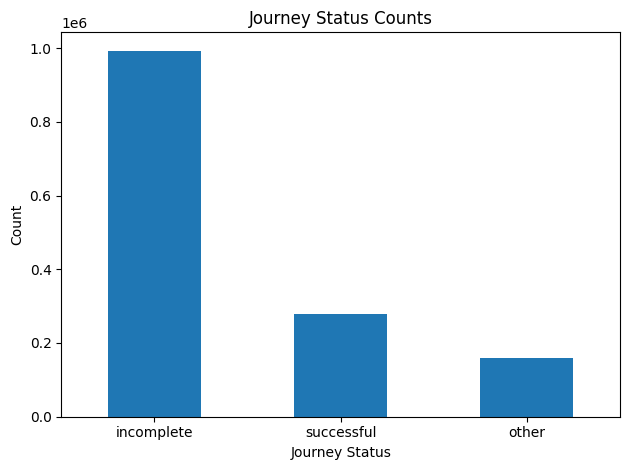


Task 5.2 - Summary stats: successful vs incomplete
shape: (2, 10)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ journey_s ┆ n_journey ┆ avg_num_a ┆ median_nu ┆ … ┆ median_nu ┆ avg_durat ┆ median_du ┆ max_dura │
│ tatus     ┆ s         ┆ ctions    ┆ m_actions ┆   ┆ m_unique_ ┆ ion_secon ┆ ration_se ┆ tion_sec │
│ ---       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ actions   ┆ ds        ┆ conds     ┆ onds     │
│ str       ┆ u32       ┆ f64       ┆ f64       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---      │
│           ┆           ┆           ┆           ┆   ┆ f64       ┆ f64       ┆ f64       ┆ i64      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ incomplet ┆ 992951    ┆ 31.223854 ┆ 21.0      ┆ … ┆ 7.0       ┆ 1.4667e7  ┆ 1.6507107 ┆ 37922054 │
│ e         ┆           ┆           ┆           ┆   ┆           ┆           ┆ e7        ┆          │
│ successfu ┆ 279148    

<Figure size 640x480 with 0 Axes>

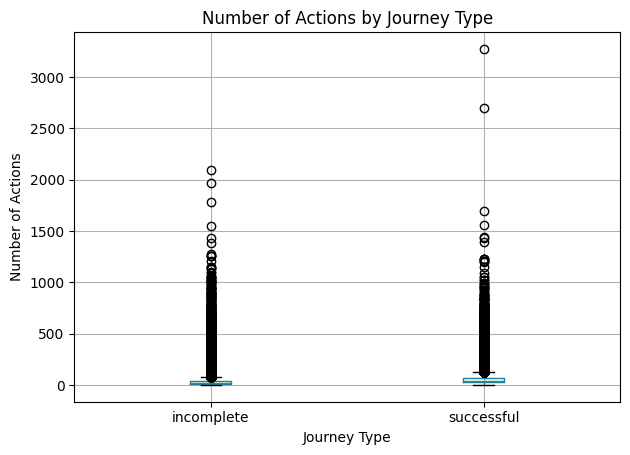

<Figure size 640x480 with 0 Axes>

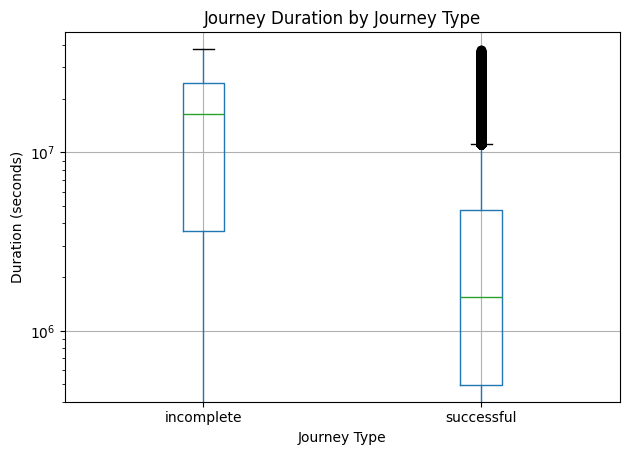

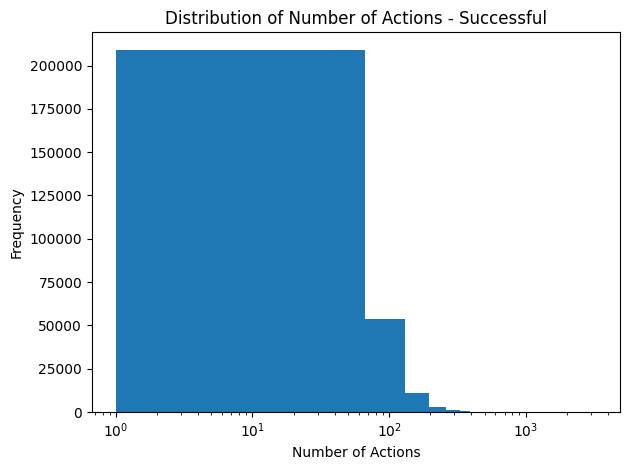

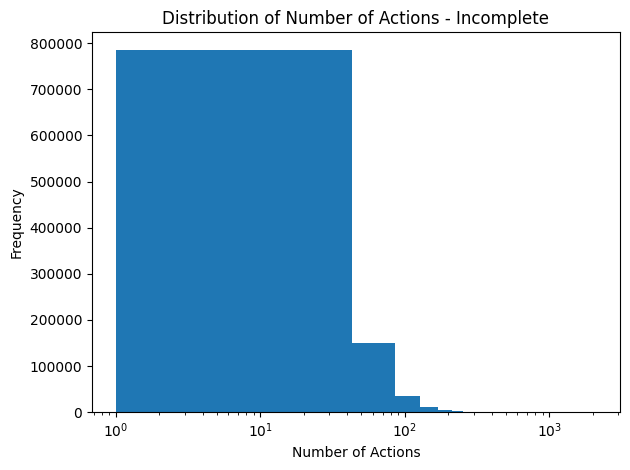

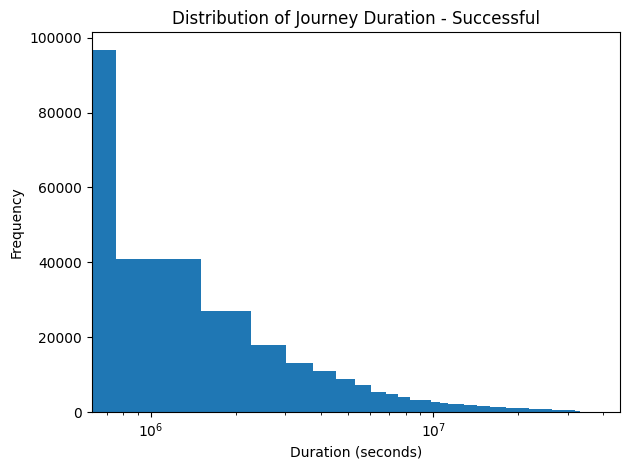

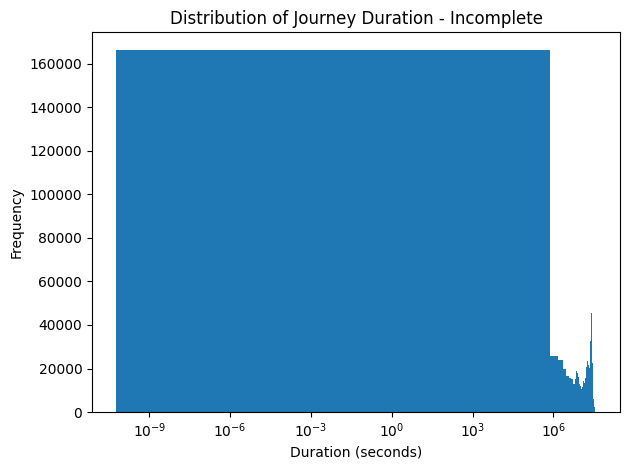


Task 5.3 - Most common first actions by group
shape: (20, 3)
┌────────────────┬──────────────┬────────┐
│ journey_status ┆ first_action ┆ count  │
│ ---            ┆ ---          ┆ ---    │
│ str            ┆ i64          ┆ u32    │
╞════════════════╪══════════════╪════════╡
│ incomplete     ┆ 2            ┆ 408349 │
│ incomplete     ┆ 12           ┆ 263049 │
│ incomplete     ┆ 19           ┆ 154248 │
│ incomplete     ┆ 21           ┆ 38895  │
│ incomplete     ┆ 4            ┆ 37809  │
│ …              ┆ …            ┆ …      │
│ successful     ┆ 1            ┆ 9600   │
│ successful     ┆ 21           ┆ 9330   │
│ successful     ┆ 15           ┆ 5206   │
│ successful     ┆ 3            ┆ 2374   │
│ successful     ┆ 5            ┆ 2193   │
└────────────────┴──────────────┴────────┘


<Figure size 640x480 with 0 Axes>

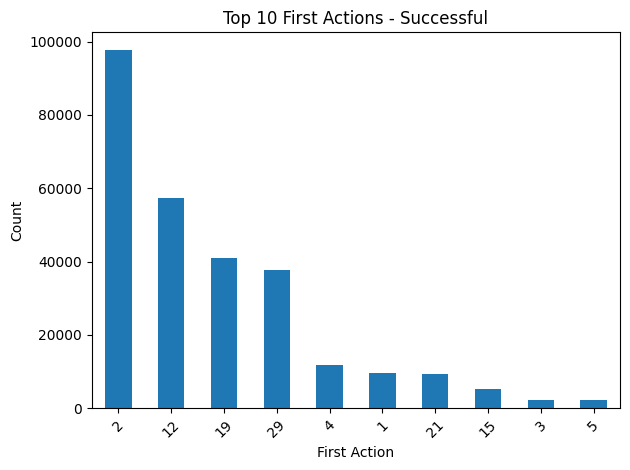

<Figure size 640x480 with 0 Axes>

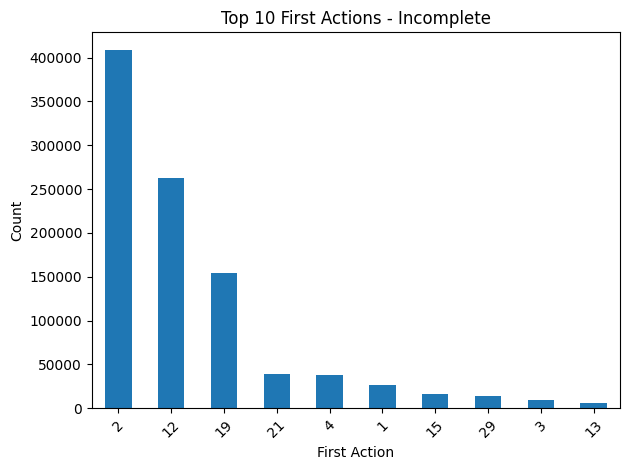


Task 5.4 - Most common last actions by group
shape: (11, 3)
┌────────────────┬─────────────┬────────┐
│ journey_status ┆ last_action ┆ count  │
│ ---            ┆ ---         ┆ ---    │
│ str            ┆ i64         ┆ u32    │
╞════════════════╪═════════════╪════════╡
│ incomplete     ┆ 1           ┆ 475284 │
│ incomplete     ┆ 21          ┆ 201329 │
│ incomplete     ┆ 4           ┆ 103085 │
│ incomplete     ┆ 24          ┆ 35020  │
│ incomplete     ┆ 12          ┆ 33443  │
│ …              ┆ …           ┆ …      │
│ incomplete     ┆ 5           ┆ 30647  │
│ incomplete     ┆ 19          ┆ 22255  │
│ incomplete     ┆ 6           ┆ 21740  │
│ incomplete     ┆ 29          ┆ 8351   │
│ successful     ┆ 28          ┆ 279148 │
└────────────────┴─────────────┴────────┘


<Figure size 640x480 with 0 Axes>

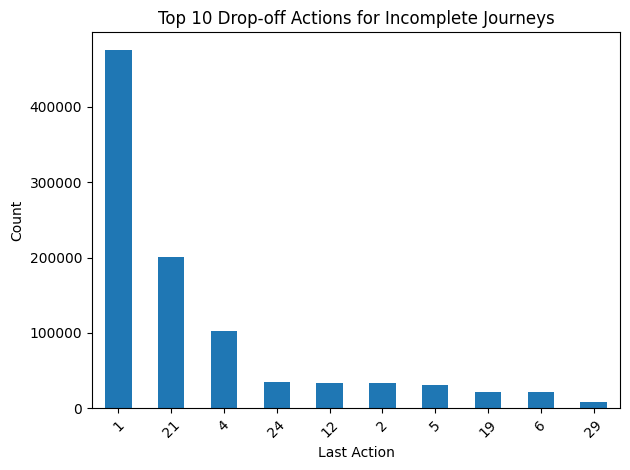


Saved labeled journeys to data/journeys_labeled.parquet

Task 6.1 - Number of labeled journeys kept for modeling:
shape: (2, 2)
┌────────────────┬────────┐
│ journey_status ┆ count  │
│ ---            ┆ ---    │
│ str            ┆ u32    │
╞════════════════╪════════╡
│ incomplete     ┆ 992951 │
│ successful     ┆ 279148 │
└────────────────┴────────┘

Task 6.2 - Training dataset preview:
shape: (5, 13)
┌────────────┬───────┬────────────┬────────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ id         ┆ label ┆ final_outc ┆ full_num_a ┆ … ┆ prefix_du ┆ avg_gap_s ┆ time_sinc ┆ prefix_ac │
│ ---        ┆ ---   ┆ ome        ┆ ctions     ┆   ┆ ration_se ┆ econds    ┆ e_prev_ac ┆ tions     │
│ str        ┆ i64   ┆ ---        ┆ ---        ┆   ┆ conds     ┆ ---       ┆ tion_seco ┆ ---       │
│            ┆       ┆ str        ┆ i64        ┆   ┆ ---       ┆ f64       ┆ nds       ┆ list[i64] │
│            ┆       ┆            ┆            ┆   ┆ i64       ┆           ┆ ---       ┆ 

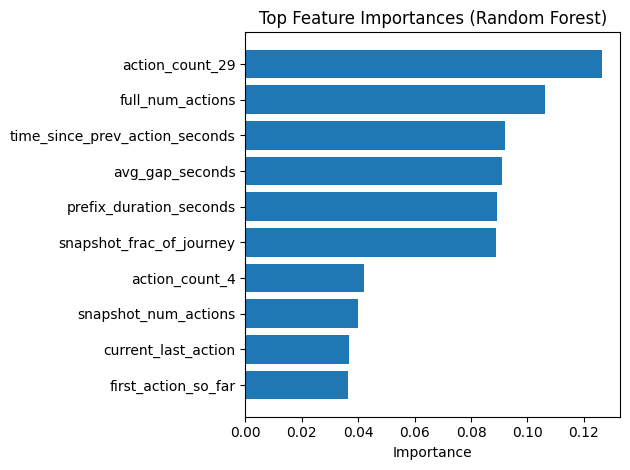


Saved submission file to data/kaggle_submission.csv
                        id  order_shipped
0      -100000293 92584960       0.140000
1   -100001025 -1674572031       0.020000
2  -1000011207 -1448136887       0.190000
3    -100001165 1418179836       0.060463
4  -1000012940 -1479669207       0.170000

Prediction summary:
count    1.272099e+06
mean     2.206222e-01
std      3.289435e-01
min      0.000000e+00
25%      0.000000e+00
50%      5.000000e-02
75%      2.100000e-01
max      1.000000e+00
Name: order_shipped, dtype: float64


In [6]:
## yulias ass#2:
# figures
import matplotlib.pyplot as plt


print("Task 3.1 - Journey length stats:")
print(actions_per_journey.select([
    pl.col("num_actions").mean().alias("mean"),
    pl.col("num_actions").median().alias("median"),
    pl.col("num_actions").std().alias("std"),
    pl.col("num_actions").min().alias("min"),
    pl.col("num_actions").max().alias("max"),
]))

print("Task 3.1 - Journey duration (seconds):")
print(journey_time_seconds.select([
    pl.col("duration_sec").mean().alias("mean_sec"),
    pl.col("duration_sec").median().alias("median_sec"),
    pl.col("duration_sec").max().alias("max_sec"),
]))

print("Task 3.2 - Most common actions:")
print(common_actions.head(10))
print("Task 3.3")
print(time_between_seconds.select([
    pl.col("time_diff_sec").mean().alias("mean_sec"),
    pl.col("time_diff_sec").median().alias("median_sec"),
    pl.col("time_diff_sec").max().alias("max_sec"),
]))

print("Task 3.4 - Distribution of journey lengths:")
print(actions_per_journey.describe())

print("Figure 1: Journey length distribution")
actions_per_journey.to_pandas().hist(column="num_actions", bins=50)
plt.xscale("log")
plt.title("Journey Length Distribution (log scale)")
plt.xlabel("Number of Actions")
plt.ylabel("Frequency")
plt.savefig(FIGURE_DIR / "fig1_journey_length.png")
plt.show()
plt.clf()

print("Figure 2: Time between actions distribution")
time_between_seconds.select("time_diff_sec").to_pandas().hist(bins=50)
plt.xscale("log")
plt.title("Time Between Actions (log scale in seconds)")
plt.xlabel("Seconds")
plt.ylabel("Frequency")
plt.savefig(FIGURE_DIR / "fig2_time_between.png")
plt.show()
plt.clf()

print("Figure 3: Most common actions")
common_actions.head(10).to_pandas().plot.bar(
    x="event_name", y="count"
)
plt.title("Top 10 Most Common Actions")
plt.xlabel("Action")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.savefig(FIGURE_DIR / "fig3_common_actions.png")
plt.show()
plt.clf()


## task 4
def flatten_journeys_parquet(input_csv_path, output_parquet_path):
    """
    Removes duplicates and flattens an event csv file so each journey (id)
    is one row, with the ordered journey stored as structs
    ["event_timestamp", "ed_id"] plus summary features.
    """
    q = pl.scan_csv(input_csv_path)
    q = q.unique(subset=["id", "ed_id", "event_timestamp"])
    q = q.with_columns(
        pl.col("event_timestamp").str.to_datetime(time_zone="UTC")
    )
    q = q.sort(["id", "event_timestamp", "ed_id"])

    df = (
        q.group_by("id")
        .agg([
            pl.struct(["event_timestamp", "ed_id"])
            .alias("journey"),

            pl.len().alias("num_actions"),
            pl.col("ed_id").n_unique().alias("num_unique_actions"),

            pl.col("event_timestamp").min().alias("start_time"),
            pl.col("event_timestamp").max().alias("end_time"),

            (pl.col("event_timestamp").max() - pl.col("event_timestamp").min())
            .dt.total_seconds()
            .alias("duration_seconds"),

            pl.col("ed_id").first().alias("first_action"),
            pl.col("ed_id").last().alias("last_action"),
        ])
    )

    df.sink_parquet(output_parquet_path)


training_csv_path = DATA_PATH
output_path = DATA_DIR / "journeys_flattened.parquet"

flatten_journeys_parquet(training_csv_path, output_path)

df = pl.read_parquet(output_path)
print("Task 4 - Flattened journey dataset preview:")
print(df.head())

## task 5
# Compare successful journeys vs incomplete journeys
# Assumption:
# - one id = one full journey
# - successful = last action is "order shipped"
# - incomplete = NOT successful and then 60+ days of inactivity after the last event

## task 5
# Compare successful journeys vs incomplete journeys
# Assumption:
# - one id = one full journey
# - successful = last action is "order shipped"
# - incomplete = NOT successful and then 60+ days of inactivity after the last event

ORDER_SHIPPED_ID = 999  # TODO: replace with the actual ed_id for "order shipped"

# read flattened journeys from task 4
journeys = pl.read_parquet(DATA_DIR / "journeys_flattened.parquet")

# get the latest timestamp in the full raw dataset
dataset_end_time = (
    pl.scan_csv(DATA_PATH)
    .with_columns(
        pl.col("event_timestamp").str.to_datetime(time_zone="UTC")
    )
    .select(pl.col("event_timestamp").max().alias("dataset_end_time"))
    .collect()
    .item()
)

## task 5
# Compare successful journeys vs incomplete journeys
# Assumption:
# - one id = one full journey
# - successful = last action is "order shipped"
# - incomplete = NOT successful and then 60+ days of inactivity after the last event

import matplotlib.pyplot as plt
import pandas as pd

ORDER_SHIPPED_ID = 28  # replace if needed

# read flattened journeys from task 4
journeys = pl.read_parquet(DATA_DIR / "journeys_flattened.parquet")

# get the latest timestamp in the full raw dataset
dataset_end_time = (
    pl.scan_csv(DATA_PATH)
    .with_columns(
        pl.col("event_timestamp").str.to_datetime(time_zone="UTC")
    )
    .select(pl.col("event_timestamp").max().alias("dataset_end_time"))
    .collect()
    .item()
)

# label journeys
journeys_labeled = journeys.with_columns([
    (pl.col("last_action") == ORDER_SHIPPED_ID).alias("is_successful"),
    (
        (pl.lit(dataset_end_time) - pl.col("end_time")).dt.total_days() >= 60
    ).alias("inactive_60_days"),
]).with_columns([
    (
        pl.when(pl.col("is_successful"))
        .then(pl.lit("successful"))
        .when((~pl.col("is_successful")) & pl.col("inactive_60_days"))
        .then(pl.lit("incomplete"))
        .otherwise(pl.lit("other"))
    ).alias("journey_status")
])

print("\nTask 5.1 - Journey status counts:")
status_counts = (
    journeys_labeled.group_by("journey_status")
    .agg(pl.len().alias("count"))
    .sort("count", descending=True)
)
print(status_counts)

# Visual 1: journey status counts
status_counts.to_pandas().plot.bar(x="journey_status", y="count", legend=False)
plt.title("Journey Status Counts")
plt.xlabel("Journey Status")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "fig4_journey_status_counts.png")
plt.show()
plt.clf()

# keep only the two groups requested
comparison_df = journeys_labeled.filter(
    pl.col("journey_status").is_in(["successful", "incomplete"])
)

# overall summary stats by group
summary_stats = (
    comparison_df.group_by("journey_status")
    .agg([
        pl.len().alias("n_journeys"),

        pl.col("num_actions").mean().alias("avg_num_actions"),
        pl.col("num_actions").median().alias("median_num_actions"),
        pl.col("num_actions").std().alias("std_num_actions"),

        pl.col("num_unique_actions").mean().alias("avg_num_unique_actions"),
        pl.col("num_unique_actions").median().alias("median_num_unique_actions"),

        pl.col("duration_seconds").mean().alias("avg_duration_seconds"),
        pl.col("duration_seconds").median().alias("median_duration_seconds"),
        pl.col("duration_seconds").max().alias("max_duration_seconds"),
    ])
    .sort("journey_status")
)

print("\nTask 5.2 - Summary stats: successful vs incomplete")
print(summary_stats)

comparison_pd = comparison_df.to_pandas()

# Visual 2: boxplot of number of actions
comparison_pd.boxplot(column="num_actions", by="journey_status")
plt.title("Number of Actions by Journey Type")
plt.suptitle("")
plt.xlabel("Journey Type")
plt.ylabel("Number of Actions")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "fig5_num_actions_boxplot.png")
plt.show()
plt.clf()

# Visual 3: boxplot of journey duration
comparison_pd.boxplot(column="duration_seconds", by="journey_status")
plt.title("Journey Duration by Journey Type")
plt.suptitle("")
plt.xlabel("Journey Type")
plt.ylabel("Duration (seconds)")
plt.yscale("log")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "fig6_duration_boxplot.png")
plt.show()
plt.clf()

# Visual 4: histogram of number of actions
for status in ["successful", "incomplete"]:
    subset = comparison_pd[comparison_pd["journey_status"] == status]
    plt.hist(subset["num_actions"], bins=50)
    plt.title(f"Distribution of Number of Actions - {status.capitalize()}")
    plt.xlabel("Number of Actions")
    plt.ylabel("Frequency")
    plt.xscale("log")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f"fig7_num_actions_hist_{status}.png")
    plt.show()
    plt.clf()

# Visual 5: histogram of duration
for status in ["successful", "incomplete"]:
    subset = comparison_pd[comparison_pd["journey_status"] == status]
    plt.hist(subset["duration_seconds"], bins=50)
    plt.title(f"Distribution of Journey Duration - {status.capitalize()}")
    plt.xlabel("Duration (seconds)")
    plt.ylabel("Frequency")
    plt.xscale("log")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f"fig8_duration_hist_{status}.png")
    plt.show()
    plt.clf()

# first action distribution by group
first_action_summary = (
    comparison_df.group_by(["journey_status", "first_action"])
    .agg(pl.len().alias("count"))
    .sort(["journey_status", "count"], descending=[False, True])
)

print("\nTask 5.3 - Most common first actions by group")
print(
    first_action_summary
    .group_by("journey_status")
    .head(10)
)

# Visual 6: top first actions by group
for status in ["successful", "incomplete"]:
    subset = (
        first_action_summary
        .filter(pl.col("journey_status") == status)
        .head(10)
        .to_pandas()
    )
    subset.plot.bar(x="first_action", y="count", legend=False)
    plt.title(f"Top 10 First Actions - {status.capitalize()}")
    plt.xlabel("First Action")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f"fig9_first_actions_{status}.png")
    plt.show()
    plt.clf()

# last action distribution by group
last_action_summary = (
    comparison_df.group_by(["journey_status", "last_action"])
    .agg(pl.len().alias("count"))
    .sort(["journey_status", "count"], descending=[False, True])
)

print("\nTask 5.4 - Most common last actions by group")
print(
    last_action_summary
    .group_by("journey_status")
    .head(10)
)

# Visual 7: top last actions for incomplete journeys (drop-off points)
dropoff_actions = (
    last_action_summary
    .filter(pl.col("journey_status") == "incomplete")
    .head(10)
    .to_pandas()
)

dropoff_actions.plot.bar(x="last_action", y="count", legend=False)
plt.title("Top 10 Drop-off Actions for Incomplete Journeys")
plt.xlabel("Last Action")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "fig10_incomplete_dropoff_actions.png")
plt.show()
plt.clf()

# optional: save labeled dataset
#jaeltyn changed to make hers work locally:
journeys_labeled.write_parquet(DATA_DIR / "journeys_labeled.parquet"
)
print("\nSaved labeled journeys to", DATA_DIR / "journeys_labeled.parquet"
)


## task 6
# Create training data for predictive modeling using Option A:
# one snapshot per journey

import math
import polars as pl

# We assume journeys_labeled already exists from Task 5 and contains:
# - id
# - journey (list of structs with event_timestamp and ed_id)
# - journey_status in {"successful", "incomplete", "other"}

# --------------------------------------------------
# 6.1 Keep only journeys with clear final outcomes
# --------------------------------------------------
model_base = journeys_labeled.filter(
    pl.col("journey_status").is_in(["successful", "incomplete"])
)

print("\nTask 6.1 - Number of labeled journeys kept for modeling:")
print(
    model_base.group_by("journey_status")
    .agg(pl.len().alias("count"))
    .sort("journey_status")
)

# --------------------------------------------------
# 6.2 Create one partial snapshot per journey
# --------------------------------------------------
# Rule:
# - Use the first 70% of actions
# - But keep at least 1 action
# - And never keep the full journey, so the model does not see the outcome step

import random

def make_snapshot(row):
    journey = row["journey"]
    n = len(journey)

    # -----------------------------
    # RANDOM TRUNCATION
    # -----------------------------
    if n <= 1:
        k = 1
    else:
        # sample a random cutoff point
        # ensures:
        # - at least 1 action
        # - never the full journey
        k = random.randint(1, n - 1)

    prefix = journey[:k]

    # -----------------------------
    # FEATURE ENGINEERING (same as before)
    # -----------------------------
    timestamps = [step["event_timestamp"] for step in prefix]
    actions = [step["ed_id"] for step in prefix]

    start_time = timestamps[0]
    current_time = timestamps[-1]
    current_last_action = actions[-1]
    first_action = actions[0]

    prefix_duration_seconds = int((current_time - start_time).total_seconds()) if k > 1 else 0
    num_actions_so_far = k
    num_unique_actions_so_far = len(set(actions))

    if k > 1:
        avg_gap_seconds = prefix_duration_seconds / (k - 1)
        time_since_prev_action_seconds = int((timestamps[-1] - timestamps[-2]).total_seconds())
    else:
        avg_gap_seconds = 0
        time_since_prev_action_seconds = 0

    return {
        "id": row["id"],
        "label": 1 if row["journey_status"] == "successful" else 0,
        "final_outcome": row["journey_status"],

        # snapshot metadata
        "full_num_actions": n,
        "snapshot_num_actions": num_actions_so_far,
        "snapshot_frac_of_journey": num_actions_so_far / n,

        # prefix-based features only
        "first_action_so_far": first_action,
        "current_last_action": current_last_action,
        "num_unique_actions_so_far": num_unique_actions_so_far,
        "prefix_duration_seconds": prefix_duration_seconds,
        "avg_gap_seconds": avg_gap_seconds,
        "time_since_prev_action_seconds": time_since_prev_action_seconds,

        # optional raw prefix sequence
        "prefix_actions": actions,
    }

snapshot_rows = [make_snapshot(row) for row in model_base.iter_rows(named=True)]
training_df = pl.DataFrame(snapshot_rows)

print("\nTask 6.2 - Training dataset preview:")
print(training_df.head())

# --------------------------------------------------
# 6.3 Add count features for common actions
# --------------------------------------------------
# This turns sequence information into model-friendly numeric columns.

top_actions = (
    training_df.explode("prefix_actions")
    .group_by("prefix_actions")
    .agg(pl.len().alias("count"))
    .sort("count", descending=True)
    .head(15)
    .get_column("prefix_actions")
    .to_list()
)

for action_id in top_actions:
    training_df = training_df.with_columns(
        pl.col("prefix_actions")
        .list.eval(pl.element() == action_id)
        .list.sum()
        .alias(f"action_count_{action_id}")
    )

print("\nTask 6.3 - Added action count features for top actions:")
print(top_actions)

# --------------------------------------------------
# 6.4 Save modeling dataset
# --------------------------------------------------
training_df.write_parquet(DATA_DIR / "journey_training_optionA.parquet")

# CSV cannot store nested list columns like prefix_actions
training_df_csv = training_df.drop("prefix_actions")
training_df_csv.write_csv(DATA_DIR / "journey_training_optionA.csv")

print("\nSaved training data to:")
print(DATA_DIR / "journey_training_optionA.parquet")
print(DATA_DIR / "journey_training_optionA.csv")

# --------------------------------------------------
# 6.5 Basic label balance check
# --------------------------------------------------
print("\nTask 6.5 - Label balance:")
print(
    training_df.group_by(["label", "final_outcome"])
    .agg(pl.len().alias("count"))
    .sort("label")
)

## task 7
# Fit a simple Random Forest model

import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# --------------------------------------------------
# 7.1 Load training data
# --------------------------------------------------
df = pl.read_parquet(DATA_DIR / "journey_training_optionA.parquet")

# drop nested column + anything not usable
df_model = df.drop(["prefix_actions", "final_outcome"])

# convert to pandas for sklearn
df_pd = df_model.to_pandas()

print("\nTask 7.1 - Training data shape:")
print(df_pd.shape)

# --------------------------------------------------
# 7.2 Encode categorical variables
# --------------------------------------------------
# (these are numeric IDs but treated as categories)
cat_cols = ["first_action_so_far", "current_last_action"]

for col in cat_cols:
    le = LabelEncoder()
    df_pd[col] = le.fit_transform(df_pd[col])

# --------------------------------------------------
# 7.3 Define features + target
# --------------------------------------------------
X = df_pd.drop(columns=["label", "id"])
y = df_pd["label"]

# --------------------------------------------------
# 7.4 Fit Random Forest (with OOB score)
# --------------------------------------------------
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    oob_score=True,
    n_jobs=-1
)

rf.fit(X, y)

print("\nTask 7.2 - OOB Accuracy:")
print(rf.oob_score_)

# --------------------------------------------------
# 7.5 Feature importance
# --------------------------------------------------
importances = rf.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print("\nTop features:")
print(importance_df.head(10))

# --------------------------------------------------
# 7.6 Plot feature importance
# --------------------------------------------------
top_k = 10
top_features = importance_df.head(top_k)

plt.barh(top_features["feature"], top_features["importance"])
plt.gca().invert_yaxis()
plt.title("Top Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "fig11_feature_importance.png")
plt.show()

## task 8
# Create a Kaggle-style submission file using the training data itself
# This is only a proof of concept because no separate test set is available.

import pandas as pd

# --------------------------------------------------
# 8.1 Use the same fitted model and feature matrix from Task 7
# --------------------------------------------------
# Assumes Task 7 already created:
# - rf
# - X
# - df_pd
#
# where:
# X = feature matrix
# df_pd["id"] = ids for each training row

train_probs = rf.predict_proba(X)[:, 1]

submission = pd.DataFrame({
    "id": df_pd["id"],
    "order_shipped": train_probs
})

# match requested format exactly
submission.to_csv(SUBMISSION_DIR / "kaggle_submission.csv", index=False)

print("\nSaved submission file to", SUBMISSION_DIR / "kaggle_submission.csv")
print(submission.head())

# optional: quick summary of predicted probabilities
print("\nPrediction summary:")
print(submission["order_shipped"].describe())

In [ ]:
# TASK 3 USING YULIAS CODE + FIXED RANDOM TRUNCATION
import polars as pl


df_test = pl.read_csv(DATA_DIR / "open_journeys1.csv")

print(df_test.head())
print(df_test.columns)
df_test = df_test.with_columns(
    pl.col("event_timestamp").str.to_datetime(time_zone="UTC")
)

test_journeys = (
    df_test.sort(["id", "event_timestamp"])
    .group_by("id")
    .agg([
        pl.col("ed_id").alias("journey"),
        pl.col("event_timestamp").alias("timestamps"),
        pl.col("event_name").last().alias("last_action"),
        pl.len().alias("num_actions"),
    ])
)

print(test_journeys.head())
import pandas as pd

def make_test_features(row):
    journey = row["journey"]
    timestamps = row["timestamps"]

    n = len(journey)

    if n > 1:
        prefix_duration = int((timestamps[-1] - timestamps[0]).total_seconds())
        avg_gap = prefix_duration / (n - 1)
        time_since_prev = int((timestamps[-1] - timestamps[-2]).total_seconds())
    else:
        prefix_duration = 0
        avg_gap = 0
        time_since_prev = 0

    return {
        "id": row["id"],

        "full_num_actions": n,
        "snapshot_num_actions": n,
        "snapshot_frac_of_journey": 1.0,

        "first_action_so_far": journey[0],
        "current_last_action": journey[-1],
        "num_unique_actions_so_far": len(set(journey)),

        "prefix_duration_seconds": prefix_duration,
        "avg_gap_seconds": avg_gap,
        "time_since_prev_action_seconds": time_since_prev,
    }

test_df = pd.DataFrame([make_test_features(r) for r in test_journeys.iter_rows(named=True)])
print(test_df.head())
test_df_enc = test_df.copy()

from sklearn.preprocessing import LabelEncoder

encoders = {}

train_df = df_pd.copy()  # this is from your training step

for col in ["first_action_so_far", "current_last_action"]:
    le = LabelEncoder()
    le.fit(train_df[col])
    encoders[col] = le
    
for col in ["first_action_so_far", "current_last_action"]:
    le = encoders[col]
    test_df_enc[col] = test_df_enc[col].map(
        lambda x: le.transform([x])[0] if x in le.classes_ else -1
    )

for col in X.columns:
    if col not in test_df_enc.columns:
        test_df_enc[col] = 0  # or 0.0 depending on type

X_test = test_df_enc[X.columns]

preds = rf.predict_proba(X_test)[:, 1]

submission = pd.DataFrame({
    "id": test_df["id"],
    "order_shipped": preds
})

submission.to_csv(SUBMISSION_DIR / "kaggle_submission.csv", index=False)
print(submission.head())


shape: (5, 8)
┌─────────────┬────────────┬───────┬──────────────┬──────────────┬─────────────┬─────────────┬─────┐
│ customer_id ┆ account_id ┆ ed_id ┆ event_name   ┆ event_timest ┆ journey_ste ┆ id          ┆ sep │
│ ---         ┆ ---        ┆ ---   ┆ ---          ┆ amp          ┆ ps_until_en ┆ ---         ┆ --- │
│ i64         ┆ i64        ┆ i64   ┆ str          ┆ ---          ┆ d           ┆ str         ┆ str │
│             ┆            ┆       ┆              ┆ str          ┆ ---         ┆             ┆     │
│             ┆            ┆       ┆              ┆              ┆ i64         ┆             ┆     │
╞═════════════╪════════════╪═══════╪══════════════╪══════════════╪═════════════╪═════════════╪═════╡
│ -1522106248 ┆ -693958153 ┆ 19    ┆ application_ ┆ 2022-12-19T2 ┆ 1           ┆ -1522106248 ┆ -   │
│             ┆            ┆       ┆ web_view     ┆ 3:05:56Z     ┆             ┆ -693958153  ┆     │
│ -1522106248 ┆ -693958153 ┆ 19    ┆ application_ ┆ 2022-12-19T2 ┆ 2         

OOB score: 0.8466880329282548
                           feature  importance
20                 action_count_29    0.126512
0                 full_num_actions    0.106249
8   time_since_prev_action_seconds    0.091897
7                  avg_gap_seconds    0.091151
6          prefix_duration_seconds    0.089158
2         snapshot_frac_of_journey    0.088864
9                   action_count_4    0.042100
1             snapshot_num_actions    0.040016
4              current_last_action    0.036691
3              first_action_so_far    0.036229
11                  action_count_5    0.032916
13                 action_count_11    0.031957
22                  action_count_7    0.029936
5        num_unique_actions_so_far    0.026566
23                  action_count_8    0.023815
10                 action_count_19    0.022399
15                  action_count_6    0.018929
12                  action_count_1    0.018605
16                  action_count_3    0.011616
19                 action_coun

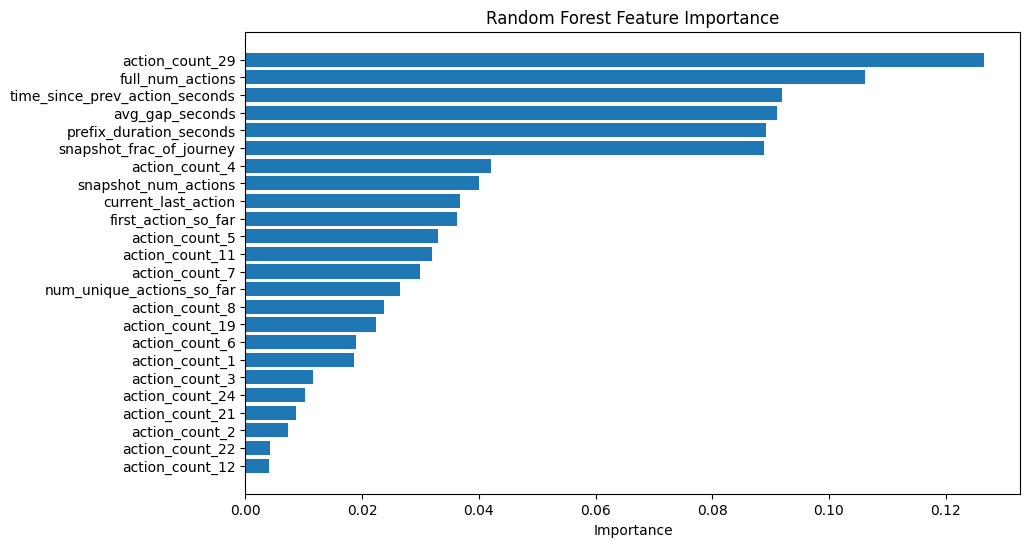

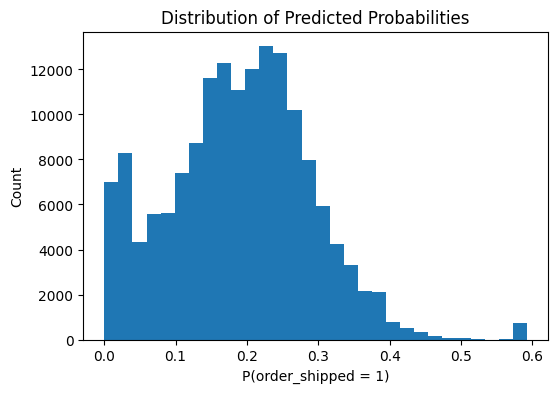

In [11]:
#figures for task 3 rf performance
print("OOB score:", rf.oob_score_)
import matplotlib.pyplot as plt
import pandas as pd

importances = rf.feature_importances_

feat_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
}).sort_values("importance", ascending=False)

print(feat_importance)
plt.figure(figsize=(10, 6))
plt.barh(feat_importance["feature"], feat_importance["importance"])
plt.gca().invert_yaxis()
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.show()

plt.figure(figsize=(6,4))
plt.hist(preds, bins=30)
plt.title("Distribution of Predicted Probabilities")
plt.xlabel("P(order_shipped = 1)")
plt.ylabel("Count")
plt.show()

In [ ]:
# getting the kaggle file
import pandas as pd

# --- STEP 1: Ensure predictions already exist ---
# preds should be your model output (rf.predict_proba(...)[:, 1])
# test_df should contain the corresponding ids

submission = pd.DataFrame({
    "id": test_df["id"],
    "order_shipped": preds
})

# --- STEP 2: Match sample submission ordering (IMPORTANT) ---
sample = pd.read_csv(DATA_DIR / "open_journeys1_flattened_all0.csv")

# Merge to ensure correct order + no missing ids
submission = sample[["id"]].merge(submission, on="id", how="left")

# Fill any missing predictions (just in case)
submission["order_shipped"] = submission["order_shipped"].fillna(0)

# --- STEP 3: Save file ---
submission.to_csv(
    SUBMISSION_DIR / "kaggle_submission_final.csv",
    index=False
)

# --- STEP 4: Quick sanity check ---
print(submission.head())
print(submission.shape)
print(submission["order_shipped"].describe())

                        id  order_shipped
0    -1000001271 551641434       0.130000
1   -100001164 -1710062169       0.392487
2    -1000073039 494887319       0.170000
3  -1000092799 -1963858498       0.140000
4    -100009516 1394046265       0.130000
(158325, 2)
count    158325.000000
mean          0.187158
std           0.101639
min           0.000000
25%           0.120000
50%           0.190000
75%           0.250000
max           0.592696
Name: order_shipped, dtype: float64


In [ ]:
#messing around chunk


import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

log_reg = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000))
])

log_reg.fit(X_train, y_train)

preds_lr = log_reg.predict_proba(X_test)[:, 1]

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

preds_rf = rf.predict_proba(X_test)[:, 1]

from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3
)

gb.fit(X_train, y_train)

preds_gb = gb.predict_proba(X_test)[:, 1]

preds_ensemble = (
    0.25 * preds_lr +
    0.25 * preds_rf +
    0.25 * preds_gb +
    0.25 * preds_hgb
)

submission = pd.DataFrame({
    "id": test_ids,   # change if your column name differs
    "target": preds_ensemble
})

submission.to_csv(SUBMISSION_DIR / "submission.csv", index=False)

try:
    from pygam import LogisticGAM

    gam = LogisticGAM().fit(X_train, y_train)

    preds_gam = gam.predict_proba(X_test)

except Exception as e:
    print("pygam not installed:", e)


import shap

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_train[:500])

shap.summary_plot(shap_values, X_train[:500])


                           feature  importance
20                 action_count_29    0.126512
0                 full_num_actions    0.106249
8   time_since_prev_action_seconds    0.091897
7                  avg_gap_seconds    0.091151
6          prefix_duration_seconds    0.089158
2         snapshot_frac_of_journey    0.088864
9                   action_count_4    0.042100
1             snapshot_num_actions    0.040016
4              current_last_action    0.036691
3              first_action_so_far    0.036229
11                  action_count_5    0.032916
13                 action_count_11    0.031957
22                  action_count_7    0.029936
5        num_unique_actions_so_far    0.026566
23                  action_count_8    0.023815
10                 action_count_19    0.022399
15                  action_count_6    0.018929
12                  action_count_1    0.018605
16                  action_count_3    0.011616
19                 action_count_24    0.010206
18           

NameError: name 'X_train' is not defined

In [ ]:
df_train.columns
